# 0. 세팅하기

## 0. 설치하기

In [1]:
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.8 MB/s eta 0:00:0000:0100:01


In [16]:
!pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable


## 1. 세팅하기

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
import duckdb as dd
import dotenv
import os
import pandas as pd

In [3]:
# 한글 폰트 지정
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 경로 확인 필요
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family=fontprop.get_name())

In [4]:
# 컬럼 모두 출력
pd.set_option('display.max_columns', None)

In [5]:
# 절대 경로 (수정해서 사용)
JSON_KEY_PATH = "key/my-projectcodeit.json"

In [6]:
# .env 파일 경로 찾기

env_path = dotenv.find_dotenv()

In [7]:
# .env 파일 불러오기  (내용이 있으면 -> True, 없으면 -> False)

dotenv.load_dotenv(
    dotenv_path=env_path,
    override=True
)

True

In [8]:
mem_con = dd.connect("mydb.duckdb")

In [9]:
HMAC_ID = os.getenv("HMAC_ID")
HMAC_PW = os.getenv("HMAC_PW")

secret_gcs = f"""
CREATE SECRET (
    TYPE GCS,
    KEY_ID '{HMAC_ID}',
    SECRET '{HMAC_PW}'
);
"""

mem_con.execute(secret_gcs)

In [10]:
mem_con.execute("FROM duckdb_secrets()").df()

,name,type,provider,persistent,storage,scope,secret_string
0,__default_gcs,gcs,config,False,memory,"[gcs://, gs://]",name=__default_gcs;type=gcs;provider=config;se...


## 2. 파일 불러오기

### 1) 기존데이블

In [132]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_user.parquet')
"""

user_df = mem_con.execute(_query).df()

In [133]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_attendance.parquet')
"""

attendance_df = mem_con.execute(_query).df()

In [134]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_group.parquet')
"""

group_df = mem_con.execute(_query).df()

In [135]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_school.parquet')
"""

school_df = mem_con.execute(_query).df()

In [10]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_timelinereport.parquet')
"""

timelinereport_df = mem_con.execute(_query).df()

In [11]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet')
"""

paymenthistory_df = mem_con.execute(_query).df()

In [12]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_failpaymenthistory.parquet')
"""

failpaymenthistory_df = mem_con.execute(_query).df()

In [13]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_receipts.parquet')
"""

event_receipts_df = mem_con.execute(_query).df()

In [14]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userwithdraw.parquet')
"""

userwithdraw_df = mem_con.execute(_query).df()

In [15]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet')
"""

userquestionrecord_df = mem_con.execute(_query).df()

In [16]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_attendance.parquet')
"""

attendance_df = mem_con.execute(_query).df()

In [17]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet')
"""

pointhistory_df = mem_con.execute(_query).df()

In [11]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionpiece.parquet')
"""

polls_questionpiece_df = mem_con.execute(_query).df()

In [12]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionset.parquet')
"""

polls_questionset_df = mem_con.execute(_query).df()

In [13]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_question.parquet')
"""

polls_question_df = mem_con.execute(_query).df()

### 2) 병합테이블

In [17]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet')
"""

paymenthistory_df = mem_con.execute(_query).df()

In [18]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet')
"""

question_df = mem_con.execute(_query).df()

In [81]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet')
"""

vote_point_df = mem_con.execute(_query).df()

In [20]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_info_df.parquet')
"""

event_info_df = mem_con.execute(_query).df()

In [30]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/user_df.parquet')
"""

total_user_df = mem_con.execute(_query).df()

### 3) duckdb에 저장

In [ ]:
# mem_con.execute("""
#                 CREATE TABLE user_df AS
#                 SELECT * FROM user_df
#                 """)

In [ ]:
# mem_con.execute("""
#                 CREATE TABLE vote_point_df AS
#                 SELECT * FROM vote_point_df
#                 """)

### 4) duckdb 확인

In [85]:
tables = mem_con.execute("SHOW TABLES").fetchall()
print(tables)

[('event_info_df',), ('paymenthistory_df',), ('question_df',), ('user_df',), ('user_df_ver2',), ('vote_point_df',)]


# 1. EDA

## 1) 월별 투표횟수

In [ ]:
# 연도_월 컬럼 생성
userquestionrecord_df['year_month'] = userquestionrecord_df['created_at'].dt.to_period('M').astype('str')

# 월별 투표 참여 건수 집계
vote_cnt_df = userquestionrecord_df['year_month'].value_counts().reset_index()
vote_cnt_df = vote_cnt_df.sort_values(by='year_month', ascending=True).reset_index(drop=True)
vote_cnt_df

,year_month,count
0,2023-04,30798
1,2023-05,1104681
2,2023-06,71341
3,2023-07,5396
4,2023-08,2050
5,2023-09,1665
6,2023-10,330
7,2023-11,253
8,2023-12,502
9,2024-01,236


## 2) 월별 포인트 사용내역

In [ ]:
# 사용내역만 남김 (음수만 남긴다.)
point_use_df = pointhistory_df[pointhistory_df['delta_point'] < 0]
point_use_df.shape

(108583, 5)

In [ ]:
# 연도_월 컬럼 생성
point_use_df.loc[:, 'year_month'] = point_use_df['created_at'].dt.to_period('M').astype(str)

# 연도_월별로 그룹화하여 count와 sum 계산
point_use_sum = point_use_df.groupby('year_month')['delta_point'].agg(['count', 'sum']).reset_index()
point_use_sum.rename(columns={'count': 'use_count', 'sum': 'total_used_points'}, inplace=True)
point_use_sum

,year_month,use_count,total_used_points
0,2023-04,929,-278700
1,2023-05,97402,-18621230
2,2023-06,8754,-1679030
3,2023-07,592,-220100
4,2023-08,292,-115200
5,2023-09,284,-99330
6,2023-10,87,-32100
7,2023-11,78,-23400
8,2023-12,63,-21700
9,2024-01,39,-15900


### 중요 그래프

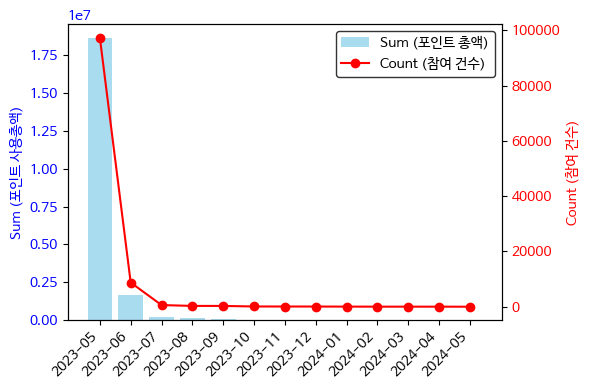

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 준비
data = {
    "year_month": ["2023-05","2023-06","2023-07","2023-08","2023-09",
                   "2023-10","2023-11","2023-12","2024-01","2024-02","2024-03",
                   "2024-04","2024-05"],
    "count": [97402, 8754, 592, 292, 284, 87, 78, 63, 39, 22, 21, 17, 3],
    "sum": [18621230, 1679030, 220100, 115200, 99330, 32100, 23400, 
            21700, 15900, 8300, 7500, 7800, 900]}

df = pd.DataFrame(data)

# 시각화
fig, ax1 = plt.subplots(figsize=(6,4))

# 막대그래프 (sum)
bar = ax1.bar(df["year_month"], df["sum"], color="skyblue", alpha=0.7, label="Sum (포인트 사용총액)")
ax1.set_ylabel("Sum (포인트 사용총액)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# 선그래프 (count)
ax2 = ax1.twinx()
line, = ax2.plot(df["year_month"], df["count"], color="red", marker="o", label="Count (참여 건수)")
ax2.set_ylabel("Count (참여 건수)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# x축 라벨
fig.autofmt_xdate(rotation=45)

# 두 범례를 하나로 합쳐서 오른쪽 상단에
handles = [bar, line]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="upper right", frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
plt.show()


## 3) 월별 가입/탈퇴인원 비교

In [ ]:
# 연도_월 컬럼 추가
userwithdraw_df['year_month'] = userwithdraw_df['created_at'].dt.to_period('M').astype('str')

# 월별 탈퇴자 수 집계
withdraw_df = userwithdraw_df['year_month'].value_counts().reset_index()
withdraw_df.columns = ['year_month', 'withdrawal_count']
withdraw_df = withdraw_df.sort_values(by='year_month').reset_index(drop=True)

withdraw_df

,year_month,withdrawal_count
0,2023-03,17
1,2023-04,2397
2,2023-05,44845
3,2023-06,9642
4,2023-07,4811
5,2023-08,2310
6,2023-09,2450
7,2023-10,1164
8,2023-11,837
9,2023-12,693


In [ ]:
# 연도_월 컬럼 생성
user_df['yser_month'] = user_df['created_at'].dt.to_period('M').astype('str')

# 월별 가입자 수 집계
signup_df = user_df['yser_month'].value_counts().reset_index()
signup_df.columns = ['year_month', 'signup_count']
signup_df = signup_df.sort_values(by='year_month').reset_index(drop=True)

signup_df

,year_month,signup_count
0,2023-03,33
1,2023-04,19060
2,2023-05,635505
3,2023-06,16737
4,2023-07,1849
5,2023-08,524
6,2023-09,605
7,2023-10,409
8,2023-11,731
9,2023-12,231


In [ ]:
# 가입자 수와 탈퇴자 수 병합

monthly_summary = signup_df.merge(withdraw_df, how='left', on='year_month')
monthly_summary

,year_month,signup_count,withdrawal_count
0,2023-03,33,17
1,2023-04,19060,2397
2,2023-05,635505,44845
3,2023-06,16737,9642
4,2023-07,1849,4811
5,2023-08,524,2310
6,2023-09,605,2450
7,2023-10,409,1164
8,2023-11,731,837
9,2023-12,231,693


## 4) 탈퇴 사유 분석

In [ ]:
reason_df = userwithdraw_df['reason'].value_counts().reset_index()
reason_df['percentage'] = round((reason_df['count']/userwithdraw_df.shape[0])*100, 3)
reason_df

,reason,count,percentage
0,기타 이유,40301,56.951
1,함께 할 친구가 없어서,14450,20.420
2,재밌는 질문이 없어서,13133,18.559
3,버그가 너무 많아서,2031,2.870
4,구독료가 너무 비싸서,730,1.032
5,admin,61,0.086
6,test,53,0.075
7,기타,5,0.007


## 5) 투표 참여율

In [ ]:
user_cnt = user_df['user_id'].nunique()
chosen_user_cnt = userquestionrecord_df['chosen_user_id'].nunique()
vote_user_cnt = userquestionrecord_df['user_id'].nunique()

print("전체 유저수 : ", user_cnt)
print("선택된 유저수 : ", chosen_user_cnt, "(", round(chosen_user_cnt/user_cnt*100,3) , "%)")
print("선택한 유저수 : ", vote_user_cnt, "(", round(vote_user_cnt/user_cnt*100, 3), "%)")

전체 유저수 :  677085
선택된 유저수 :  15426 ( 2.278 %)
선택한 유저수 :  4849 ( 0.716 %)


# 2. 피쳐엔지니어링

## 1) user_df 병합

In [ ]:
# user_df에 attendance_df merge하기
merged_df_1 = user_df.merge(attendance_df[['attendance_date_list', 'user_id']], how='left', left_on='id', right_on='user_id').drop(columns=['user_id'])  # 불필요한 컬럼 삭제

# 리스트 형식 count로 변경하여 반영
import json

def fast_len(x):
    if x == '[]' or pd.isna(x):
        return 0
    try:
        return len(json.loads(x))
    except:
        return 0

merged_df_1['friend_count'] = merged_df_1['friend_id_list'].apply(fast_len)
merged_df_1['block_user_count'] = merged_df_1['block_user_id_list'].apply(fast_len)
merged_df_1['hide_user_id_count'] = merged_df_1['hide_user_id_list'].apply(fast_len)
merged_df_1['attendance_date_count'] = merged_df_1['attendance_date_list'].apply(fast_len)

# is_superuser, is_staff 1인 경우 제거
merged_df_1 = merged_df_1[(
    (merged_df_1['is_superuser'] == 0) &
    (merged_df_1['is_staff'] == 0)
)]

# id를 user_id로 컬럼명 변경
merged_df_1 = merged_df_1.rename(columns={'id': 'user_id'})

# user_df에 group_df, school_df merge하기
merged_df_2 = merged_df_1.merge(group_df, how='left', left_on='group_id', right_on='id')
merged_df_3 = merged_df_2.merge(school_df, how='left', left_on='school_id', right_on='id')


# is_superuser, is_staff, friend_id_list 컬럼 제거
merged_df_3 = merged_df_3.drop(columns=['is_superuser', 'is_staff', 'friend_id_list', 'block_user_id_list', 'hide_user_id_list', 'attendance_date_list', 'id_x', 'id_y'])

# null값 제거
merged_df_3 = merged_df_3.dropna()

# # pandas로 GCS에 데이터 저장
# def write_data_to_gcs(df, JSON_KEY_PATH, DATASET_PATH, file_name):
#     df.to_parquet(
#         path=f'{DATASET_PATH}/{file_name}.parquet',
#         engine='pyarrow',
#         compression='gzip',
#         index=False,
#         storage_options={'token' : JSON_KEY_PATH}
#     )
# write_data_to_gcs(merged_df_3, JSON_KEY_PATH, "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes", "total_user_df")


In [128]:
merged_df_3.head()

,user_id,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,friend_count,block_user_count,hide_user_id_count,attendance_date_count,grade,class_num,school_id,address,student_count,school_type
10,833024,F,393,0,2023-03-31 09:05:51.903699,N,0,0,0,0,35.0,41,0,0,0,1.0,10.0,5464.0,경기도 군포시,158.0,H
11,833041,F,885000006,1,2023-03-31 14:32:36.425315,N,1,8,0,0,149.0,67,0,0,53,3.0,1.0,314.0,충청남도 천안시 동남구,131.0,H
12,833112,M,290,1,2023-03-31 15:55:48.870381,N,0,1,0,0,37.0,13,0,0,3,3.0,1.0,281.0,충청남도 천안시 서북구,347.0,H
13,833113,M,2801,1,2023-03-31 15:56:52.300066,N,0,3,0,49,38.0,23,0,0,0,1.0,3.0,272.0,충청남도 천안시 서북구,339.0,H
14,833154,F,5883,1,2023-03-31 15:57:39.008717,N,0,1,0,17,61.0,126,0,0,1,1.0,12.0,272.0,충청남도 천안시 서북구,339.0,H


In [129]:
merged_df_3.isna().sum()

user_id                  0
gender                   0
point                    0
is_push_on               0
created_at               0
ban_status               0
report_count             0
alarm_count              0
pending_chat             0
pending_votes            0
group_id                 0
friend_count             0
block_user_count         0
hide_user_id_count       0
attendance_date_count    0
grade                    0
class_num                0
school_id                0
address                  0
student_count            0
school_type              0
dtype: int64

In [130]:
merged_df_3.shape

(676987, 21)

## 2) 질문테이블 : 질문piece, 질문set, 질문 테이블 병합

In [17]:
# polls_questionset_df정규화 대상 copy
df = polls_questionset_df.copy()

# question_piece_id_list 컬럼 정규화 (explode 사용)
df['question_piece_id_list'] = df['question_piece_id_list'].apply(eval)  # 문자열로 저장된 리스트를 진짜 리스트로 변환
normalized_df = df.explode('question_piece_id_list')[['id', 'question_piece_id_list']]

# 열 이름 바꾸기
normalized_df = normalized_df.rename(columns={'question_piece_id_list': 'question_piece_id'})

# 정규화 후 df랑 기존 df 병합
merged_df = normalized_df.merge(
    df[['id', 'opening_time', 'status', 'created_at', 'user_id']],
    how='left',
    on='id'
)

# polls_questionpiece_df 병합
question_df = merged_df.merge(
    polls_questionpiece_df, 
    how='left', 
    left_on='question_piece_id', 
    right_on='id',
    suffixes=('_set','_piece'))

# polls_question_df  질문내용과 병합
question_df2 = question_df.merge(
  polls_question_df,
  how='left',
  left_on='question_id',
  right_on='id'
)

# null 제거
question_df_notnull = question_df2.dropna()
question_df_notnull

# 컬럼 정리하기
final_question_df = question_df_notnull[['id_set', 'question_piece_id', 'opening_time', 'status',
                                          'created_at_set', 'user_id', 'is_voted', 'is_skipped', 'created_at_piece',
                                          'question_id',  'question_text']]

# pandas로 GCS에 데이터 저장
def write_data_to_gcs(df, JSON_KEY_PATH, DATASET_PATH, file_name):
    df.to_parquet(
        path=f'{DATASET_PATH}/{file_name}.parquet',
        engine='pyarrow',
        compression='gzip',
        index=False,
        storage_options={'token' : JSON_KEY_PATH}
    )
write_data_to_gcs(final_question_df, JSON_KEY_PATH, "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes", "question_df")


In [16]:
final_question_df

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,is_voted,is_skipped,created_at_piece,question_id,question_text
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,244.0,대학교에서 학생회장할 것 같은 사람은?
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,183.0,나의 자존감을 가장 많이 높여줬던 사람은?
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,101.0,미래의 틱톡커는?
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,209.0,항상 좋은 냄새가 나는 사람은?
...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,960.0,가장 인싸일 것 같은 친구는?
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1402.0,가장 리더쉽 있을 것 같은 사람
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1676.0,화장 전후 가장 비슷할 것 같은 사람은?
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람


questionset 1정규화

In [132]:
polls_questionset_df.head()

,id,question_piece_id_list,opening_time,status,created_at,user_id
0,99817,"[998458, 998459, 998460, 998461, 998462, 99846...",2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99830,"[998588, 998589, 998590, 998591, 998592, 99859...",2023-04-28 12:28:07,F,2023-04-28 12:28:07,849438
2,99840,"[998689, 998691, 998693, 998695, 998697, 99869...",2023-04-28 12:28:38,F,2023-04-28 12:28:38,847375
3,99841,"[998688, 998690, 998692, 998694, 998696, 99869...",2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446
4,99848,"[998768, 998769, 998770, 998771, 998772, 99877...",2023-04-28 12:28:57,F,2023-04-28 12:28:57,849477


In [133]:
print("shape : ", polls_questionpiece_df.shape)
print("id 갯수 : ", polls_questionpiece_df['id'].nunique())

shape :  (1265476, 5)


id 갯수 :  1265476


In [134]:
# 정규화 대상 DataFrame
df = polls_questionset_df.copy()

# 리스트 컬럼 정규화 (explode 사용)
df['question_piece_id_list'] = df['question_piece_id_list'].apply(eval)  # 문자열로 저장된 리스트를 진짜 리스트로 변환
normalized_df = df.explode('question_piece_id_list')[['id', 'question_piece_id_list']]

# 열 이름 바꾸기 (선택사항)
normalized_df = normalized_df.rename(columns={'question_piece_id_list': 'question_piece_id'})

# 결과 확인
normalized_df.head()

,id,question_piece_id
0,99817,998458
0,99817,998459
0,99817,998460
0,99817,998461
0,99817,998462


In [135]:
merged_df = normalized_df.merge(
    df[['id', 'opening_time', 'status', 'created_at', 'user_id']],
    how='left',
    on='id'
)

In [136]:
# 정규화 완료 테이블
merged_df.head()

,id,question_piece_id,opening_time,status,created_at,user_id
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436


In [137]:
# question_piece_id 중복값 확인
merged_df['question_piece_id'].duplicated().sum()

0

In [138]:
merged_df['question_piece_id'].nunique()

1583840

questionpiece 테이블 합치기

In [139]:
polls_questionpiece_df.head()

,id,is_voted,created_at,question_id,is_skipped
0,998458,1,2023-04-28 12:27:22,252,0
1,998459,1,2023-04-28 12:27:22,244,0
2,998460,1,2023-04-28 12:27:22,183,0
3,998461,1,2023-04-28 12:27:22,101,0
4,998462,1,2023-04-28 12:27:22,209,0


In [140]:
merged_df.head()

,id,question_piece_id,opening_time,status,created_at,user_id
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436


In [141]:
question_df = merged_df.merge(
    polls_questionpiece_df, 
    how='left', 
    left_on='question_piece_id', 
    right_on='id',
    suffixes=('_set','_piece'))

In [142]:
question_df.head(20)

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0
5,99817,998463,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998463.0,1.0,2023-04-28 12:27:22,239.0,0.0
6,99817,998464,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998464.0,1.0,2023-04-28 12:27:22,146.0,0.0
7,99817,998465,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998465.0,1.0,2023-04-28 12:27:22,297.0,0.0
8,99817,998466,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998466.0,1.0,2023-04-28 12:27:22,294.0,0.0
9,99817,998467,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998467.0,1.0,2023-04-28 12:27:22,201.0,0.0


In [143]:
question_df.isna().sum()

id_set                    0
question_piece_id         0
opening_time              0
status                    0
created_at_set            0
user_id                   0
id_piece             318364
is_voted             318364
created_at_piece     318364
question_id          318364
is_skipped           318364
dtype: int64

In [144]:
nan_rows = question_df[question_df.isna().any(axis=1)]
nan_rows

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped
18,99830,998596,2023-04-28 12:28:07,F,2023-04-28 12:28:07,849438,NaN,NaN,NaT,NaN,NaN
30,99841,998688,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
31,99841,998690,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
32,99841,998692,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
35,99841,998698,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1583694,20835070,208351465,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583695,20835070,208351466,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583696,20835070,208351467,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583698,20835070,208351469,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN


In [145]:
nan_rows['status'].value_counts()

status
F    318351
O        11
C         2
Name: count, dtype: int64

polls_question_df랑 merge

In [146]:
polls_question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [147]:
question_df2 = question_df.merge(
  polls_question_df,
  how='left',
  left_on='question_id',
  right_on='id'
)

In [148]:
question_df2.head()

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped,id,question_text,created_at
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0,244.0,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0,183.0,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-01 11:09:14
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0,101.0,미래의 틱톡커는?,2023-03-31 15:22:54
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0,209.0,항상 좋은 냄새가 나는 사람은?,2023-04-01 11:09:20


null 제거

In [149]:
question_df2.isna().sum()

id_set                    0
question_piece_id         0
opening_time              0
status                    0
created_at_set            0
user_id                   0
id_piece             318364
is_voted             318364
created_at_piece     318364
question_id          318364
is_skipped           318364
id                   318364
question_text        318364
created_at           318364
dtype: int64

In [150]:
question_df_notnull = question_df2.dropna()
question_df_notnull

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped,id,question_text,created_at
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0,244.0,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0,183.0,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-01 11:09:14
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0,101.0,미래의 틱톡커는?,2023-03-31 15:22:54
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0,209.0,항상 좋은 냄새가 나는 사람은?,2023-04-01 11:09:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385226.0,0.0,2024-05-07 11:32:30,960.0,0.0,960.0,가장 인싸일 것 같은 친구는?,2023-05-15 14:00:19
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385227.0,0.0,2024-05-07 11:32:30,1402.0,0.0,1402.0,가장 리더쉽 있을 것 같은 사람,2023-05-15 14:03:19
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385228.0,0.0,2024-05-07 11:32:30,1676.0,0.0,1676.0,화장 전후 가장 비슷할 것 같은 사람은?,2023-06-02 08:06:24
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385229.0,0.0,2024-05-07 11:32:30,3115.0,0.0,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람,2023-06-02 08:07:08


In [151]:
question_df_notnull.shape

(1265476, 14)

columns 정리

In [152]:
question_df_notnull.columns

Index(['id_set', 'question_piece_id', 'opening_time', 'status',
       'created_at_set', 'user_id', 'id_piece', 'is_voted', 'created_at_piece',
       'question_id', 'is_skipped', 'id', 'question_text', 'created_at'],
      dtype='object')

In [153]:
final_question_df = question_df_notnull[['id_set', 'question_piece_id', 'opening_time', 'status',
                                          'created_at_set', 'user_id', 'is_voted', 'is_skipped', 'created_at_piece',
                                          'question_id',  'question_text']]

In [154]:
final_question_df

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,is_voted,is_skipped,created_at_piece,question_id,question_text
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,244.0,대학교에서 학생회장할 것 같은 사람은?
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,183.0,나의 자존감을 가장 많이 높여줬던 사람은?
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,101.0,미래의 틱톡커는?
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,209.0,항상 좋은 냄새가 나는 사람은?
...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,960.0,가장 인싸일 것 같은 친구는?
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1402.0,가장 리더쉽 있을 것 같은 사람
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1676.0,화장 전후 가장 비슷할 것 같은 사람은?
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람


추출하기

In [155]:
# mem_con.execute("""
#                COPY final_question_df TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet' (FORMAT PARQUET);
#                """)

## 4) 통합유저테이블 생성

In [ ]:
# 빅쿼리에서 데이터 가져오기
import pandas as pd
from google.oauth2 import service_account

JSON_KEY_PATH = '/home/sprintda07/final_project_team3/key/my-projectcodeit.json'
PROJECT_ID = 'my-projectcodeit'
LOCATION = 'asia-northeast3'

# 서비스 계정 키 파일을 사용하여 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(JSON_KEY_PATH)

df = pd.read_gbq(
  query ="SELECT * FROM final_project.user_df",
  project_id=PROJECT_ID,
  credentials=credentials,
  location=LOCATION
)

# user_df 복사본 생성
user_df_ver3 = df.copy()

# school_type과 grade를 합쳐서 school_grade 컬럼 생성
user_df_ver3['school_grade'] = user_df_ver3.apply(
    lambda row: f"{row['school_type']}_{int(row['grade'])}" if pd.notna(row['grade']) else None,
    axis=1
)

# 포인트 사용/획득 데이터프레임 생성
use_df = pointhistory_df[pointhistory_df['delta_point'] < 0]
get_df = pointhistory_df[pointhistory_df['delta_point'] > 0]

use_user_df = use_df['user_id'].value_counts().reset_index(name='pointuse_cnt')
get_user_df = get_df['user_id'].value_counts().reset_index(name='pointget_cnt')

# 투표참여 횟수 데이터프레임 생성
vote_df = userquestionrecord_df['user_id'].value_counts().reset_index(name='vote_cnt')
chosen_df = userquestionrecord_df['chosen_user_id'].value_counts().reset_index(name='chosen_cnt')
chosen_df.rename(columns = {'chosen_user_id':'user_id'}, inplace=True)

# 이벤트 참여횟수 데이터프레임 생성
event_df = event_receipts_df['user_id'].value_counts().reset_index(name='event_cnt')

# 구매관련 데이터프레임 생성
buy_df = paymenthistory_df['user_id'].value_counts().reset_index(name='buy_cnt')
buyfail_df = failpaymenthistory_df['user_id'].value_counts().reset_index(name='buyfail_cnt')

# 친구 신고 관련 데이터프레임 생성
friendreport_df = timelinereport_df['user_id'].value_counts().reset_index(name='friendreport_cnt')

# 데이터 합치기
# 기준 DataFrame 복사
merged_df = user_df_ver3.copy()

# 기존 컬럼 목록 저장
original_columns = set(merged_df.columns)

# 병합 대상 DataFrame 리스트
df_list = [use_user_df, get_user_df, vote_df, chosen_df, event_df, buy_df, buyfail_df, friendreport_df]

# merge 실행
for df in df_list:
    merged_df = merged_df.merge(df, on='user_id', how='left')

# 새로 생긴 컬럼만 골라서 fillna(0)
new_columns = list(set(merged_df.columns) - original_columns)
merged_df[new_columns] = merged_df[new_columns].fillna(0)

# 주소 데이터 정제
addresses  = merged_df['address'].unique()

# 전체 시도 이름 + 줄임말 모두 대응
province_mapping = {
    '서울': '서울특별시', '서울특별시': '서울특별시',
    '부산': '부산광역시', '부산광역시': '부산광역시',
    '대구': '대구광역시', '대구광역시': '대구광역시',
    '인천': '인천광역시', '인천광역시': '인천광역시',
    '광주': '광주광역시', '광주광역시': '광주광역시',
    '대전': '대전광역시', '대전광역시': '대전광역시',
    '울산': '울산광역시', '울산광역시': '울산광역시',
    '세종': '세종특별자치시', '세종특별자치시': '세종특별자치시',
    '경기': '경기도', '경기도': '경기도',
    '강원': '강원도', '강원도': '강원도',
    '충북': '충청북도', '충청북도': '충청북도',
    '충남': '충청남도', '충청남도': '충청남도',
    '전북': '전라북도', '전라북도': '전라북도',
    '전남': '전라남도', '전라남도': '전라남도',
    '경북': '경상북도', '경상북도': '경상북도',
    '경남': '경상남도', '경상남도': '경상남도',
    '제주': '제주특별자치도', '제주특별자치도': '제주특별자치도'
}

def extract_province(address):
    for short, full in province_mapping.items():
        if short in address:
            return full
    return None

# 적용
merged_df['province'] = merged_df['address'].apply(extract_province)

# 필요없는 컬럼 제외
merged_df.drop(columns=['group_id', 'grade', 'class_num', 'school_id', 'school_type', 'address'], inplace=True)

# null값 제거
merged_df.dropna(subset=['province'], inplace=True)


### 1. 리스트 형식 숫자로 넣기

In [ ]:
import json

def fast_len(x):
    if x == '[]' or pd.isna(x):
        return 0
    try:
        return len(json.loads(x))
    except:
        return 0

user_df['friend_count'] = user_df['friend_id_list'].apply(fast_len)
user_df['block_user_id_count'] = user_df['block_user_id_list'].apply(fast_len)
user_df['hide_user_id_count'] = user_df['hide_user_id_list'].apply(fast_len)
user_df['attendance_count'] = user_df['attendance_date_list'].apply(fast_len)

In [ ]:
user_df.head()

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,friend_count,block_user_id_count,hide_user_id_count,attendance_count
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN,NaN,None,NaN,NaN,NaN,None,NaN,None,6,0,0,0
1,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None,43,0,0,0
2,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1.0,219728.0,"[""2023-05-29""]",1.0,1.0,1.0,None,NaN,None,51,0,0,1
3,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1.0,315353.0,"[""2023-06-05"", ""2023-06-06""]",1.0,1.0,1.0,None,NaN,None,57,0,0,2
4,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None,18,0,0,0


In [ ]:
user_df['friend_id_list'][1]

'[833025, 832642, 982531, 879496, 838541, 837521, 833041, 832151, 1082907, 1426466, 1541413, 1577131, 837806, 834486, 834358, 1575225, 1576252, 837950, 1446852, 1577930, 841037, 1577938, 832340, 831958, 849624, 837338, 1577954, 849763, 862823, 1577703, 834415, 833009, 834289, 833011, 842865, 833013, 856050, 833017, 833018, 833022, 833023, 1580476, 1580855]'

In [ ]:
# 1. 임시 뷰 생성
mem_con.register('temp_user_df', user_df)

# 2. 뷰를 테이블로 변환
mem_con.execute("CREATE TABLE user_df_ver2 AS SELECT * FROM temp_user_df")

# 3. 임시 뷰 삭제 (선택사항)
mem_con.execute("DROP VIEW temp_user_df")

In [ ]:
mem_con.execute("SHOW TABLES").fetchall()

[('event_info_df',),
 ('paymenthistory_df',),
 ('question_df',),
 ('user_df',),
 ('user_df_ver2',),
 ('vote_point_df',)]

### 2. 학교 관련 컬럼 정리

In [ ]:
query = """
    SELECT * EXCLUDE (friend_id_list, block_user_id_list, hide_user_id_list, attendance_date_list, id_attendance)
    FROM user_df_ver2
    """
    
user_df_ver2 = mem_con.execute(query).df()

In [ ]:
user_df_ver2.head(5)

,user_id,is_superuser,is_staff,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,grade,class_num,school_id,address,student_count,school_type,friend_count,block_user_id_count,hide_user_id_count,attendance_count
0,831956,1,1,None,600,0,2023-03-29 03:44:14.047130,N,0,0,0,0,NaN,NaN,NaN,NaN,None,NaN,None,6,0,0,0
1,831962,0,0,F,2248,1,2023-03-29 05:18:56.162368,N,253,40878,5499,110,12.0,2.0,1.0,1.0,None,NaN,None,43,0,0,0
2,832151,0,0,M,1519,0,2023-03-29 12:56:34.989468,N,0,37,0,47,1.0,1.0,1.0,1.0,None,NaN,None,51,0,0,1
3,832340,0,0,F,57,1,2023-03-29 12:56:35.020790,N,0,19,0,21,1.0,1.0,1.0,1.0,None,NaN,None,57,0,0,2
4,832520,0,0,M,1039,0,2023-03-29 12:56:35.049311,N,0,29,0,15,12.0,2.0,1.0,1.0,None,NaN,None,18,0,0,0


In [ ]:
user_df_ver2.columns

Index(['user_id', 'is_superuser', 'is_staff', 'gender', 'point', 'is_push_on',
       'created_at', 'ban_status', 'report_count', 'alarm_count',
       'pending_chat', 'pending_votes', 'group_id', 'grade', 'class_num',
       'school_id', 'address', 'student_count', 'school_type', 'friend_count',
       'block_user_id_count', 'hide_user_id_count', 'attendance_count'],
      dtype='object')

In [ ]:
columns = ['created_at', 'user_id', 'is_superuser', 'is_staff', 'gender', 'point', 'is_push_on',
       'ban_status', 'report_count', 'alarm_count','friend_count',
       'block_user_id_count', 'hide_user_id_count', 'attendance_count',
       'pending_chat', 'pending_votes', 'group_id', 'grade', 'class_num',
       'school_id', 'address', 'student_count', 'school_type', ]

In [ ]:
copy_df = user_df_ver2[columns]
user_df_ver3 = copy_df.copy()
user_df_ver3.head()

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,group_id,grade,class_num,school_id,address,student_count,school_type
0,2023-03-29 03:44:14.047130,831956,1,1,None,600,0,N,0,0,6,0,0,0,0,0,NaN,NaN,NaN,NaN,None,NaN,None
1,2023-03-29 05:18:56.162368,831962,0,0,F,2248,1,N,253,40878,43,0,0,0,5499,110,12.0,2.0,1.0,1.0,None,NaN,None
2,2023-03-29 12:56:34.989468,832151,0,0,M,1519,0,N,0,37,51,0,0,1,0,47,1.0,1.0,1.0,1.0,None,NaN,None
3,2023-03-29 12:56:35.020790,832340,0,0,F,57,1,N,0,19,57,0,0,2,0,21,1.0,1.0,1.0,1.0,None,NaN,None
4,2023-03-29 12:56:35.049311,832520,0,0,M,1039,0,N,0,29,18,0,0,0,0,15,12.0,2.0,1.0,1.0,None,NaN,None


In [ ]:
user_df_ver3['school_grade'] = user_df_ver3.apply(
    lambda row: f"{row['school_type']}_{int(row['grade'])}" if pd.notna(row['grade']) else None,
    axis=1
)


In [ ]:
user_df_ver3.drop(columns=['group_id', 'grade', 'class_num', 'school_id', 'school_type'], inplace=True)

In [ ]:
user_df_ver3.head()

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade
0,2023-03-29 03:44:14.047130,831956,1,1,None,600,0,N,0,0,6,0,0,0,0,0,None,NaN,None
1,2023-03-29 05:18:56.162368,831962,0,0,F,2248,1,N,253,40878,43,0,0,0,5499,110,None,NaN,None_2
2,2023-03-29 12:56:34.989468,832151,0,0,M,1519,0,N,0,37,51,0,0,1,0,47,None,NaN,None_1
3,2023-03-29 12:56:35.020790,832340,0,0,F,57,1,N,0,19,57,0,0,2,0,21,None,NaN,None_1
4,2023-03-29 12:56:35.049311,832520,0,0,M,1039,0,N,0,29,18,0,0,0,0,15,None,NaN,None_2


### 3. 포인트 사용/적립횟수 테이블 만들기

In [107]:
pointhistory_df.head()

,id,delta_point,created_at,user_id,user_question_record_id
0,790629,9,2023-04-28 12:27:49,849436,771777.0
1,790652,9,2023-04-28 12:28:02,849436,771800.0
2,790664,5,2023-04-28 12:28:09,849436,771812.0
3,790680,13,2023-04-28 12:28:16,849436,771828.0
4,790703,5,2023-04-28 12:28:26,849436,771851.0


In [109]:
use_df = pointhistory_df[pointhistory_df['delta_point'] < 0]
get_df = pointhistory_df[pointhistory_df['delta_point'] > 0]

In [112]:
use_user_df = use_df['user_id'].value_counts().reset_index(name='pointuse_cnt')
use_user_df

,user_id,pointuse_cnt
0,935887,343
1,1224497,341
2,882900,319
3,1335294,310
4,1412186,308
...,...,...
4604,877517,1
4605,876485,1
4606,871610,1
4607,883838,1


In [113]:
get_user_df = get_df['user_id'].value_counts().reset_index(name='pointget_cnt')
get_user_df

,user_id,pointget_cnt
0,849103,2955
1,1159163,2323
2,1213990,2125
3,1206529,2110
4,1037925,2059
...,...,...
5032,919142,1
5033,850216,1
5034,1296016,1
5035,1567383,1


### 4. 투표참여 횟수

In [114]:
userquestionrecord_df.head(3)

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0


In [116]:
vote_df = userquestionrecord_df['user_id'].value_counts().reset_index(name='vote_cnt')
vote_df

,user_id,vote_cnt
0,849103,2786
1,876509,1708
2,856042,1701
3,1213990,1695
4,1159163,1656
...,...,...
4844,985719,1
4845,885441,1
4846,875207,1
4847,951655,1


In [134]:
chosen_df = userquestionrecord_df['chosen_user_id'].value_counts().reset_index(name='chosen_cnt')
chosen_df.rename(columns = {'chosen_user_id':'user_id'}, inplace=True)
chosen_df

,user_id,chosen_cnt
0,913265,1239
1,1206668,1054
2,1402487,1049
3,1122686,1042
4,994573,997
...,...,...
15421,1455789,1
15422,1136841,1
15423,982443,1
15424,1316470,1


### 5. 이벤트 참여

In [120]:
event_receipts_df.head()

,id,created_at,event_id,user_id,plus_point
0,2,2023-06-22 09:25:16,1,1193618,500
1,3,2023-06-22 09:38:53,1,928351,500
2,4,2023-06-22 10:32:15,1,904872,500
3,5,2023-06-22 13:03:06,1,974697,500
4,6,2023-06-22 13:40:38,1,1168260,500


In [121]:
event_df = event_receipts_df['user_id'].value_counts().reset_index(name='event_cnt')
event_df

,user_id,event_cnt
0,1577954,2
1,1193618,1
2,1084334,1
3,1222661,1
4,1230407,1
...,...,...
303,977341,1
304,996039,1
305,984884,1
306,970922,1


### 6. 구매 관련 횟수

In [124]:
paymenthistory_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [125]:
buy_df = paymenthistory_df['user_id'].value_counts().reset_index(name='buy_cnt')
buy_df

,user_id,buy_cnt
0,1527451,60
1,1246471,51
2,1141603,35
3,1204373,34
4,1142775,30
...,...,...
59187,1222184,1
59188,1311286,1
59189,1237480,1
59190,1032813,1


In [126]:
failpaymenthistory_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.200,A,2023-05-14 05:49:22,1055891
1,7,heart.777,A,2023-05-14 08:17:21,1152151
2,8,heart.777,A,2023-05-14 10:11:46,986200
3,9,heart.1000,A,2023-05-14 11:53:09,1028261
4,10,heart.777,A,2023-05-14 12:30:47,1235730


In [127]:
buyfail_df = failpaymenthistory_df['user_id'].value_counts().reset_index(name='buyfail_cnt')
buyfail_df

,user_id,buyfail_cnt
0,927108,2
1,1211047,2
2,1322662,2
3,1236620,1
4,1129520,1
...,...,...
155,1386668,1
156,1056623,1
157,1315626,1
158,1393509,1


### 7. 친구 신고횟수

In [129]:
timelinereport_df.head()

,id,reason,created_at,reported_user_id,user_id,user_question_record_id
0,28,타인을 사칭함,2023-05-06 04:44:57,874587,885082,3920588
1,37,친구를 비하하거나 조롱하는 어투,2023-05-06 05:41:19,881048,881298,4018679
2,46,친구를 비하하거나 조롱하는 어투,2023-05-06 06:26:59,887882,881945,4120914
3,64,허위 사실 언급,2023-05-06 07:07:46,888610,893684,4143049
4,65,허위 사실 언급,2023-05-06 07:07:52,888610,893684,4143049


In [130]:
friendreport_df = timelinereport_df['user_id'].value_counts().reset_index(name='friendreport_cnt')
friendreport_df

,user_id,friendreport_cnt
0,1343904,19
1,1173995,10
2,1291813,9
3,944838,7
4,914800,6
...,...,...
110,1180707,1
111,1152348,1
112,1207183,1
113,1139317,1


### 8. 데이터 합치기

In [135]:
# 기준 DataFrame 복사
merged_df = user_df_ver3.copy()

# 기존 컬럼 목록 저장
original_columns = set(merged_df.columns)

# 병합 대상 DataFrame 리스트
df_list = [use_user_df, get_user_df, vote_df, chosen_df, event_df, buy_df, buyfail_df, friendreport_df]

# merge 실행
for df in df_list:
    merged_df = merged_df.merge(df, on='user_id', how='left')

# 새로 생긴 컬럼만 골라서 fillna(0)
new_columns = list(set(merged_df.columns) - original_columns)
merged_df[new_columns] = merged_df[new_columns].fillna(0)


In [136]:
merged_df.head()

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
0,2023-03-29 03:44:14.047130,831956,1,1,None,600,0,N,0,0,6,0,0,0,0,0,None,NaN,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-03-29 05:18:56.162368,831962,0,0,F,2248,1,N,253,40878,43,0,0,0,5499,110,None,NaN,None_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023-03-29 12:56:34.989468,832151,0,0,M,1519,0,N,0,37,51,0,0,1,0,47,None,NaN,None_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023-03-29 12:56:35.020790,832340,0,0,F,57,1,N,0,19,57,0,0,2,0,21,None,NaN,None_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023-03-29 12:56:35.049311,832520,0,0,M,1039,0,N,0,29,18,0,0,0,0,15,None,NaN,None_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [141]:
merged_df.shape

(677085, 27)

In [138]:
merged_df.isna().sum()

created_at              0
user_id                 0
is_superuser            0
is_staff                0
gender                  2
point                   0
is_push_on              0
ban_status              0
report_count            0
alarm_count             0
friend_count            0
block_user_id_count     0
hide_user_id_count      0
attendance_count        0
pending_chat            0
pending_votes           0
address                98
student_count          98
school_grade            3
pointuse_cnt            0
pointget_cnt            0
vote_cnt                0
chosen_cnt              0
event_cnt               0
buy_cnt                 0
buyfail_cnt             0
friendreport_cnt        0
dtype: int64

In [137]:
merged_df.describe()

,created_at,user_id,is_superuser,is_staff,point,is_push_on,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,student_count,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
count,677085,6.770850e+05,677085.000000,677085.000000,6.770850e+05,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,676987.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000
mean,2023-05-15 22:46:01.709212,1.212969e+06,0.000003,0.000004,3.039145e+03,0.843098,0.037291,0.946646,53.327700,0.028552,0.764663,3.282198,0.098469,84.630518,206.806301,0.160368,3.294025,1.798235,1.798235,0.000456,0.140514,0.000241,0.000307
min,2023-03-29 03:44:14.047130,8.319560e+05,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-05-09 01:35:23.126587,1.028075e+06,0.000000,0.000000,4.000000e+02,1.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,2.000000,136.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-05-13 10:50:57.476214,1.211729e+06,0.000000,0.000000,9.650000e+02,1.000000,0.000000,1.000000,49.000000,0.000000,0.000000,0.000000,0.000000,29.000000,199.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2023-05-20 07:49:47.800350,1.397906e+06,0.000000,0.000000,2.183000e+03,1.000000,0.000000,1.000000,70.000000,0.000000,0.000000,4.000000,0.000000,122.000000,272.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2024-05-09 08:31:17.710824,1.583733e+06,1.000000,1.000000,8.850000e+08,1.000000,253.000000,40878.000000,1373.000000,178.000000,3557.000000,310.000000,5712.000000,3352.000000,578.000000,343.000000,2955.000000,2786.000000,1239.000000,2.000000,60.000000,2.000000,19.000000
std,NaN,2.138971e+05,0.001719,0.002105,1.076020e+06,0.363709,0.588105,56.114858,32.226571,0.447539,13.935422,7.307679,11.087769,123.262688,97.384453,3.087997,47.258420,28.702858,23.069547,0.021427,0.647290,0.015797,0.036980


### 9. 결측치 등 제거

In [155]:
# 필터링 조건 (제외할 조건을 반대로 표현)
filtered_df = merged_df[
    (merged_df['is_superuser'] != 1) &
    (merged_df['is_staff'] != 1) &
    (merged_df['gender'].notna()) &
    (merged_df['school_grade'] != 'None') &
    (merged_df['address'].notna()) &
    (merged_df['student_count'].notna())
]

In [156]:
print(merged_df.shape)
print(filtered_df.shape)

(677085, 27)
(676987, 27)


address, student_count, school_grade도 none이 들어가거나 포함되면 지울까?

In [157]:
filtered_df.head(5)

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
11,2023-03-31 09:05:51.903699,833024,0,0,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2023-03-31 14:32:36.425315,833041,0,0,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
13,2023-03-31 15:55:48.870381,833112,0,0,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
14,2023-03-31 15:56:52.300066,833113,0,0,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
15,2023-03-31 15:57:39.008717,833154,0,0,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [158]:
filtered_df.columns

Index(['created_at', 'user_id', 'is_superuser', 'is_staff', 'gender', 'point',
       'is_push_on', 'ban_status', 'report_count', 'alarm_count',
       'friend_count', 'block_user_id_count', 'hide_user_id_count',
       'attendance_count', 'pending_chat', 'pending_votes', 'address',
       'student_count', 'school_grade', 'pointuse_cnt', 'pointget_cnt',
       'vote_cnt', 'chosen_cnt', 'event_cnt', 'buy_cnt', 'buyfail_cnt',
       'friendreport_cnt'],
      dtype='object')

컬럼(is_superuser, is_staff) 제거

In [159]:
columns = ['created_at', 'user_id', 'gender', 'point', 'is_push_on', 'ban_status', 'report_count', 'alarm_count',
       'friend_count', 'block_user_id_count', 'hide_user_id_count', 'attendance_count', 'pending_chat', 'pending_votes', 'address',
       'student_count', 'school_grade', 'pointuse_cnt', 'pointget_cnt', 'vote_cnt', 'chosen_cnt', 'event_cnt', 'buy_cnt', 'buyfail_cnt',
       'friendreport_cnt']

In [160]:
final_user_df = filtered_df[columns]
final_user_df.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
11,2023-03-31 09:05:51.903699,833024,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
13,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
14,2023-03-31 15:56:52.300066,833113,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
15,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 10. 추출하기

In [ ]:
# mem_con.execute("""
#                 COPY final_user_df TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/final_user_df.parquet' (FORMAT PARQUET);
#                 """)

# 3. 분석

## 1) 친구 수와 활동성의 관계

In [ ]:
from google.oauth2 import service_account
from google.cloud import bigquery

PROJECT_ID = "my-projectcodeit"
LOCATION = "asia-northeast3"
# 절대 경로 (수정해서 사용)
JSON_KEY_PATH = "key/my-projectcodeit.json"

credentials = service_account.Credentials.from_service_account_file(JSON_KEY_PATH)

In [ ]:
# 서비스 계정 JSON 파일 경로 설정
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/home/sprintda07/final_project_team3/key/my-projectcodeit.json'

# BigQuery → PyArrow → DuckDB
client = bigquery.Client()
query_total_user_df = "SELECT * FROM `my-projectcodeit.final_project.total_user_df`"
total_user_df = client.query(query_total_user_df).to_arrow()

# PyArrow 테이블을 DuckDB에서 'total_user_df'라는 이름으로 등록(사실 이걸 하지 않아도 duckDB에서 바로 사용 가능)
mem_con.register("total_user_df", total_user_df)

# DuckDB에서 직접 사용
final_user_df = mem_con.execute("SELECT * FROM total_user_df").df()

In [ ]:
final_user_df.head()

,user_id,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,friend_count,block_user_count,hide_user_id_count,attendance_date_count,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,province
0,1005961,F,2884,1,2023-05-08 11:36:21.504116,N,0,1,0,3,79,0,2,2,239.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,충청북도
1,1138991,F,226,1,2023-05-11 13:59:12.348719,N,0,0,0,1,44,0,0,0,239.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,충청북도
2,1151280,F,1920,1,2023-05-11 22:53:47.019996,N,0,1,0,138,25,1,0,1,239.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,충청북도
3,1155721,F,1948,1,2023-05-12 02:30:02.890229,N,0,1,0,75,43,0,0,0,239.0,H_1,0.0,0.0,0.0,61.0,0.0,0.0,0.0,0.0,충청북도
4,1158283,F,554,1,2023-05-12 04:59:41.499122,N,0,1,0,44,18,0,0,0,239.0,H_1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,충청북도


In [ ]:
final_user_df.shape

(676984, 25)

In [ ]:
final_user_df['friend_count'].describe()

count    676984.000000
mean         53.332367
std          32.225902
min           0.000000
25%          31.000000
50%          49.000000
75%          70.000000
max        1373.000000
Name: friend_count, dtype: float64

In [ ]:
# 친구수 분포 확인
print("=== 친구수 기본 통계 ===")
print(final_user_df['friend_count'].describe())

# 분위수로 4구간 나누기 (가장 간단)
final_user_df['friend_group_quartile'] = pd.qcut(final_user_df['friend_count'], 
                                                q=4, 
                                                labels=['1구간(하위25%)', '2구간(25-50%)', 
                                                       '3구간(50-75%)', '4구간(상위25%)'])

print("\n=== 분위수 4구간 결과 ===")
print(final_user_df['friend_group_quartile'].value_counts().sort_index())

=== 친구수 기본 통계 ===
count    676984.000000
mean         53.332367
std          32.225902
min           0.000000
25%          31.000000
50%          49.000000
75%          70.000000
max        1373.000000
Name: friend_count, dtype: float64

=== 분위수 4구간 결과 ===
friend_group_quartile
1구간(하위25%)     172210
2구간(25-50%)    175502
3구간(50-75%)    163412
4구간(상위25%)     165860
Name: count, dtype: int64


In [ ]:
# 구간별 통계 계산
range_stats = final_user_df.groupby('friend_group_quartile', observed=False)['friend_count'].agg([
    'min', 'max', 'mean', 'count'
]).round(1)

# 컬럼명 한글로 변경
range_stats.columns = ['최소값', '최대값', '평균', '사용자수']

range_stats


,최소값,최대값,평균,사용자수
friend_group_quartile,,,,
1구간(하위25%),0,31,19.3,172210
2구간(25-50%),32,49,40.5,175502
3구간(50-75%),50,70,59.2,163412
4구간(상위25%),71,1373,96.5,165860


In [ ]:
# 분석할 주요 컬럼들 선택
key_columns = [
    'friend_count',      # 친구수 (기준)
    'point',            # 포인트
    'attendance_date_count', # 출석 횟수  
    'vote_cnt',         # 투표 참여
    'chosen_cnt',        # 투표에서 선택됨
    'buy_cnt',          # 구매 횟수
    'alarm_count',      # 알람 수
    'pointuse_cnt',     # 포인트 사용 횟수
    'pointget_cnt'      # 포인트 획득 횟수
]

# 구간별 평균값 비교
group_means = final_user_df.groupby('friend_group_quartile', observed=False)[key_columns].mean().round(2)
group_means

,friend_count,point,attendance_date_count,vote_cnt,chosen_cnt,buy_cnt,alarm_count,pointuse_cnt,pointget_cnt
friend_group_quartile,,,,,,,,,
1구간(하위25%),19.26,1141.54,2.46,0.62,0.45,0.07,0.89,0.06,0.99
2구간(25-50%),40.48,1811.54,3.50,1.60,1.32,0.13,0.83,0.15,2.69
3구간(50-75%),59.24,7232.30,3.57,2.15,2.00,0.16,0.83,0.19,3.82
4구간(상위25%),96.49,2112.32,3.63,2.89,3.51,0.20,0.85,0.26,5.81


In [ ]:
from scipy import stats

test_metrics = ['vote_cnt', 'buy_cnt', 'chosen_cnt', 'pointuse_cnt', 'pointget_cnt']

print("=== 정규성 검정 (Shapiro-Wilk) ===\n")

for metric in test_metrics:
    print(f"- {metric}:")
    
    normality_violated = False
    
    for group in final_user_df['friend_group_quartile'].cat.categories:
        group_data = final_user_df[final_user_df['friend_group_quartile'] == group][metric].dropna()
        
        # 5000개로 샘플링
        if len(group_data) > 5000:
            group_data = group_data.sample(5000, random_state=42)
        
        if len(group_data) >= 3:
            _, p_value = stats.shapiro(group_data)
            status = "❌ 비정규" if p_value < 0.05 else "✅ 정규"
            print(f"   {group}: p={p_value:.6f} {status} (n={len(group_data)})")
            
            if p_value < 0.05:
                normality_violated = True
    
    result = "비정규분포" if normality_violated else "정규분포"
    print(f"   → 결과: {result}\n")

=== 정규성 검정 (Shapiro-Wilk) ===

- vote_cnt:
   1구간(하위25%): p=0.000000 ❌ 비정규 (n=5000)
   2구간(25-50%): p=0.000000 ❌ 비정규 (n=5000)
   3구간(50-75%): p=0.000000 ❌ 비정규 (n=5000)
   4구간(상위25%): p=0.000000 ❌ 비정규 (n=5000)
   → 결과: 비정규분포

- buy_cnt:
   1구간(하위25%): p=0.000000 ❌ 비정규 (n=5000)
   2구간(25-50%): p=0.000000 ❌ 비정규 (n=5000)
   3구간(50-75%): p=0.000000 ❌ 비정규 (n=5000)
   4구간(상위25%): p=0.000000 ❌ 비정규 (n=5000)
   → 결과: 비정규분포

- chosen_cnt:
   1구간(하위25%): p=0.000000 ❌ 비정규 (n=5000)
   2구간(25-50%): p=0.000000 ❌ 비정규 (n=5000)
   3구간(50-75%): p=0.000000 ❌ 비정규 (n=5000)
   4구간(상위25%): p=0.000000 ❌ 비정규 (n=5000)
   → 결과: 비정규분포

- pointuse_cnt:
   1구간(하위25%): p=0.000000 ❌ 비정규 (n=5000)
   2구간(25-50%): p=0.000000 ❌ 비정규 (n=5000)
   3구간(50-75%): p=0.000000 ❌ 비정규 (n=5000)
   4구간(상위25%): p=0.000000 ❌ 비정규 (n=5000)
   → 결과: 비정규분포

- pointget_cnt:
   1구간(하위25%): p=0.000000 ❌ 비정규 (n=5000)
   2구간(25-50%): p=0.000000 ❌ 비정규 (n=5000)
   3구간(50-75%): p=0.000000 ❌ 비정규 (n=5000)
   4구간(상위25%): p=0.000000 ❌ 비정규 (n=5000)
   → 결

In [ ]:
from scipy import stats

test_metrics = ['vote_cnt', 'buy_cnt', 'chosen_cnt', 'pointuse_cnt', 'pointget_cnt']

print("=== 등분산성 검정 (Levene's test) ===\n")

for metric in test_metrics:
    print(f"- {metric}:")
    
    # 각 그룹의 데이터 수집
    groups = []
    for group in final_user_df['friend_group_quartile'].cat.categories:
        group_data = final_user_df[final_user_df['friend_group_quartile'] == group][metric].dropna()
        groups.append(group_data)
    
    # Levene's test 실행
    levene_stat, p_value = stats.levene(*groups)
    
    # 결과 출력
    status = "❌ 등분산성 위반" if p_value < 0.05 else "✅ 등분산성 만족"
    print(f"   Levene 통계량: {levene_stat:.4f}")
    print(f"   p값: {p_value:.6f} {status}")
    
    result = "등분산성 위반" if p_value < 0.05 else "등분산성 만족"
    print(f"   → 결과: {result}\n")

=== 등분산성 검정 (Levene's test) ===

- vote_cnt:
   Levene 통계량: 186.8901
   p값: 0.000000 ❌ 등분산성 위반
   → 결과: 등분산성 위반

- buy_cnt:
   Levene 통계량: 1089.6315
   p값: 0.000000 ❌ 등분산성 위반
   → 결과: 등분산성 위반

- chosen_cnt:
   Levene 통계량: 530.2162
   p값: 0.000000 ❌ 등분산성 위반
   → 결과: 등분산성 위반

- pointuse_cnt:
   Levene 통계량: 124.4311
   p값: 0.000000 ❌ 등분산성 위반
   → 결과: 등분산성 위반

- pointget_cnt:
   Levene 통계량: 309.2318
   p값: 0.000000 ❌ 등분산성 위반
   → 결과: 등분산성 위반



In [ ]:
from scipy import stats

test_metrics = ['vote_cnt', 'buy_cnt', 'chosen_cnt', 'pointuse_cnt', 'pointget_cnt']

print("=== 크루스칼-왈리스 검정 (비모수 검정) ===\n")

for metric in test_metrics:
    print(f"- {metric}:")
    
    # 각 그룹의 데이터 수집
    groups = []
    for group in final_user_df['friend_group_quartile'].cat.categories:
        group_data = final_user_df[final_user_df['friend_group_quartile'] == group][metric].dropna()
        groups.append(group_data)
    
    # 크루스칼-왈리스 검정 실행
    h_stat, p_value = stats.kruskal(*groups)
    
    # 결과 출력
    status = "✅ 구간 간 유의한 차이 있음" if p_value < 0.05 else "❌ 구간 간 유의한 차이 없음"
    print(f"   H 통계량: {h_stat:.3f}")
    print(f"   p값: {p_value:.6f} {status}")
    
    result = "유의함" if p_value < 0.05 else "유의하지 않음"
    print(f"   → 결과: {result}\n")

=== 크루스칼-왈리스 검정 (비모수 검정) ===

- vote_cnt:
   H 통계량: 290.628
   p값: 0.000000 ✅ 구간 간 유의한 차이 있음
   → 결과: 유의함

- buy_cnt:
   H 통계량: 5097.032
   p값: 0.000000 ✅ 구간 간 유의한 차이 있음
   → 결과: 유의함

- chosen_cnt:
   H 통계량: 1608.101
   p값: 0.000000 ✅ 구간 간 유의한 차이 있음
   → 결과: 유의함

- pointuse_cnt:
   H 통계량: 370.987
   p값: 0.000000 ✅ 구간 간 유의한 차이 있음
   → 결과: 유의함

- pointget_cnt:
   H 통계량: 198.973
   p값: 0.000000 ✅ 구간 간 유의한 차이 있음
   → 결과: 유의함

